In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/featured_data.csv")

In [5]:
features = [
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4",
    "Rolling_Std_4"
]

In [7]:
X = df[features]
y = df["Weekly_Sales"]

In [8]:
print(X.shape)
print(y.shape)

(6431, 14)
(6431,)


In [9]:
split_index = int(len(df) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(5144, 14)
(1287, 14)
(5144,)
(1287,)


In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [12]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = model.predict(X_test)

In [14]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison_df.head(10)

,Actual,Predicted
0,1231752.54,1.485113e+06
1,788633.42,1.058913e+06
2,339407.94,5.788355e+05
3,2057637.86,1.752013e+06
4,877055.32,9.670773e+05
5,1621031.70,1.109634e+06
6,1650405.21,1.804491e+06
7,1171834.47,9.210434e+05
8,435790.74,9.287921e+05
9,506973.17,9.106025e+05


# metrics

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("RMSE:", rmse)
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

MAE: 295078.57134195603
RMSE: 359736.5260764001
R² Score: 0.5455646644593479


# non-linear pattern found

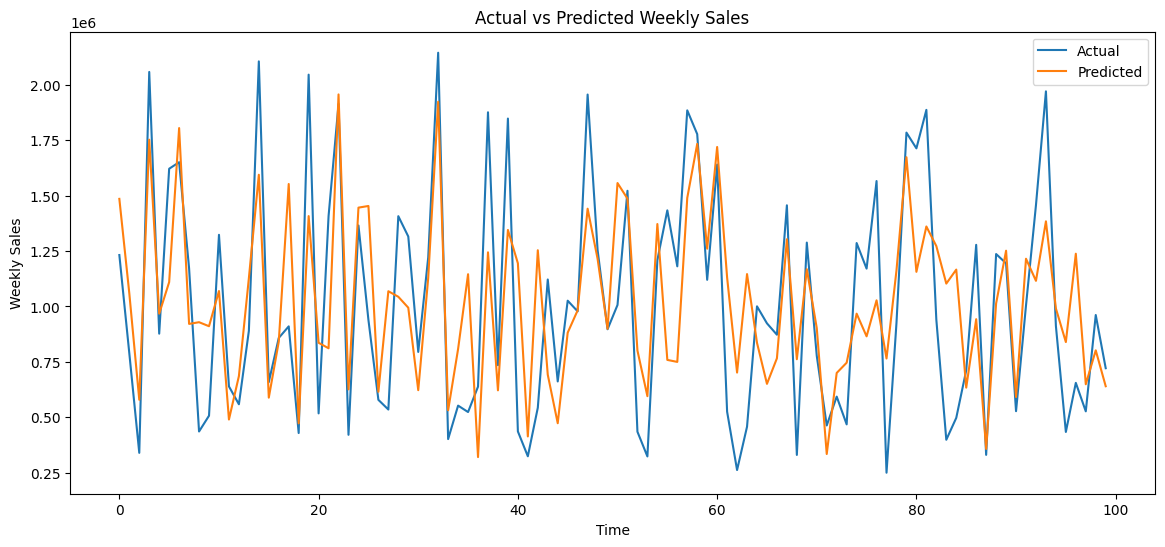

In [16]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Time")
plt.ylabel("Weekly Sales")

plt.legend()

plt.show()